In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import pickle
import seaborn as sns
from matplotlib import gridspec
import plot_helper_functions as hf


/opt/anaconda3/envs/Surabie_S_clean_v2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [29]:
# settings
non_feature_cols = ['SMILES', 'MP', 'MP_label', 'Type']
figure_output_dir = "../8_EDA"
data_types = ['L', 'H', 'All']
color_scheme = {
    'L': '#4c72b0', 
    'H': '#dd8452',
    'All': '#55a868', 
    'Purple': '#8172b3',
    'Red': "#e74c3c",
    'Extra': '#4d4d4d'}

In [25]:
all_data_path = '../0_data/processed_data/data_with_all_features_scaled.parquet'
L_data_path = '../0_data/processed_data/data_with_selected_features_LGB_L.parquet'
H_data_path = '../0_data/processed_data/data_with_selected_features_LGB_H.parquet'

In [27]:
H_cols = pd.read_parquet(figure_3_H_data_path).columns.tolist()
L_cols = pd.read_parquet(figure_3_L_data_path).columns.tolist()

# combine the two column lists and remove duplicates
combined_cols = list(dict.fromkeys(H_cols + L_cols))

print(f"H model features: {len(H_cols)}")
print(f"L model features: {len(L_cols)}")
print(f"Combined features: {len(combined_cols)}")

#figure_3_data_ = pd.read_parquet(figure_3_all_data_path)[combined_cols]
figure_data_ = pd.read_parquet(figure_3_all_data_path)

figure_data = figure_3_data_[figure_3_data_['Type'] == 'Train']

print(f"Figure data shape: {figure_3_data.shape}")

H model features: 59
L model features: 93
Combined features: 100
Figure data shape: (12054, 388)


In [28]:
figure_data

,MACCS_0,MACCS_1,MACCS_10,MACCS_100,MACCS_101,MACCS_102,MACCS_103,MACCS_104,MACCS_105,MACCS_106,...,RDKit_fr_term_acetylene,RDKit_fr_tetrazole,RDKit_fr_thiazole,RDKit_fr_thiocyan,RDKit_fr_thiophene,RDKit_fr_unbrch_alkane,RDKit_fr_urea,RDKit_qed,SMILES,Type
0,0.0,0.0,0.0,-0.372678,1.605258,-0.476047,-0.437830,-0.433652,1.555810,-0.484941,...,-0.072601,-0.058421,-0.128257,-0.017216,-0.121843,-0.168229,-0.147667,-1.155375,COc1ccc(cc1)C1(C)CCc2c(-c3c1cc(o3)C)c1c(o2)ccc...,Train
1,0.0,0.0,0.0,-0.372678,1.605258,-0.476047,-0.437830,-0.433652,1.555810,-0.484941,...,-0.072601,-0.058421,-0.128257,-0.017216,-0.121843,-0.168229,-0.147667,-0.552575,C[C@H]1[C@@H]2CC[C@@H]3[C@](C1=O)(C2)C(=O)OC[C...,Train
2,0.0,0.0,0.0,-0.372678,-0.622953,-0.476047,-0.437830,-0.433652,-0.642752,-0.484941,...,-0.072601,-0.058421,-0.128257,-0.017216,-0.121843,-0.168229,-0.147667,0.482897,Cc1cc(Br)c(cc1Br)C,Train
3,0.0,0.0,0.0,-0.372678,-0.622953,-0.476047,-0.437830,-0.433652,-0.642752,-0.484941,...,-0.072601,-0.058421,-0.128257,-0.017216,-0.121843,-0.168229,-0.147667,0.495026,OC(=O)c1ccc(c(c1)F)C,Train
4,0.0,0.0,0.0,-0.372678,1.605258,-0.476047,-0.437830,-0.433652,1.555810,-0.484941,...,-0.072601,-0.058421,-0.128257,-0.017216,-0.121843,-0.168229,-0.147667,0.704817,OC(=O)C1CC(=O)c2c1cccc2,Train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12049,0.0,0.0,0.0,-0.372678,-0.622953,-0.476047,2.283989,-0.433652,-0.642752,-0.484941,...,-0.072601,-0.058421,-0.128257,-0.017216,-0.121843,-0.168229,-0.147667,0.737705,N#CCC(=O)c1ccc(c(c1)Cl)Cl,Train
12050,0.0,0.0,0.0,-0.372678,-0.622953,-0.476047,-0.437830,-0.433652,-0.642752,-0.484941,...,-0.072601,-0.058421,-0.128257,-0.017216,-0.121843,13.347631,-0.147667,-3.024733,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC,Train
12051,0.0,0.0,0.0,-0.372678,1.605258,-0.476047,-0.437830,-0.433652,1.555810,-0.484941,...,-0.072601,-0.058421,-0.128257,-0.017216,-0.121843,-0.168229,-0.147667,0.755355,OC(=O)c1ccc2c(c1)CCCC2,Train
12052,0.0,0.0,0.0,-0.372678,-0.622953,-0.476047,-0.437830,-0.433652,-0.642752,-0.484941,...,-0.072601,-0.058421,-0.128257,-0.017216,-0.121843,-0.168229,-0.147667,-0.703209,COc1cccc(c1P(c1c(OC)cccc1OC)c1c(OC)cccc1OC)OC,Train


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/8_EDA/plot_helper_functions.py:271: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x=x_col, y=prop, order=group_order,
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/8_EDA/plot_helper_functions.py:276: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_LABEL_MAP.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/8_EDA/plot_helper_functions.py:271: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x=x_col, y=prop, order=group_order,
/Users/sdl5_mp/Documents/G

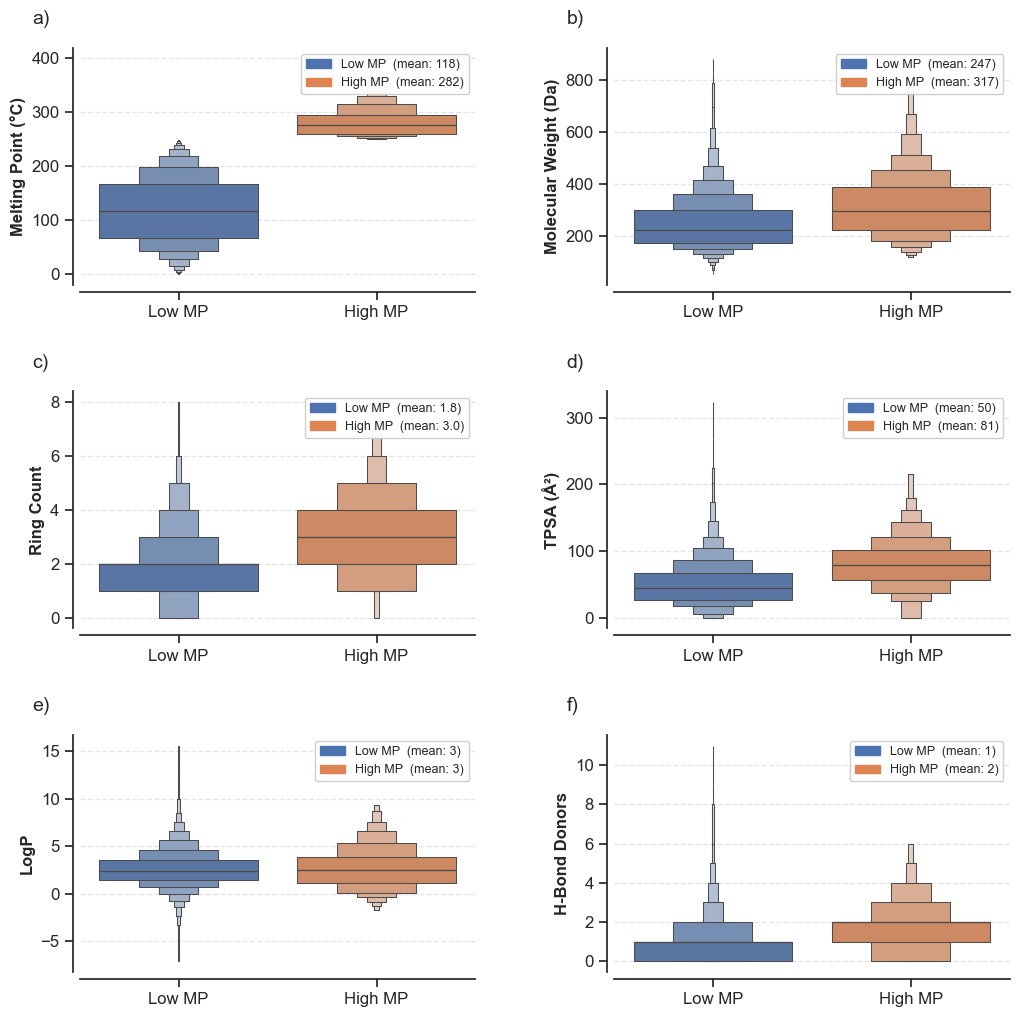

In [30]:
# 1. Added two more features (e.g., LogP and H-Bond Donors)
properties = [
    ('MP',        'Melting Point (°C)'),
    ('MW',        'Molecular Weight (Da)'),
    ('RingCount', 'Ring Count'),
    ('TPSA',      'TPSA (Å²)'),
    ('LogP',      'LogP'),           # New Feature 1
    ('HBD','H-Bond Donors'),  # New Feature 2
]

sns.set_theme(style="ticks", font_scale=1.1)
fig = plt.figure(figsize=(12, 12)) # Adjusted height for the extra row

# 2. Redefined GridSpec to 3 rows and 2 columns for the 6 features
gs = gridspec.GridSpec(3, 2, figure=fig, wspace=0.35, hspace=0.45)

# 3. Simple list of all 6 positions in the 3x2 grid
prop_positions = [(0, 0), (0, 1), (1, 0), (1, 1), (2, 0), (2, 1)]

for i, ((row, col), (prop, label)) in enumerate(zip(prop_positions, properties)):
    ax = fig.add_subplot(gs[row, col])
    
    # 4. Calling the original helper function with identical parameters
    hf.property_plot(figure_3_data, prop, label, ax=ax, x_col='MP_label',
                  color_scheme=color_scheme, smiles_col='SMILES', show_outliers=False,
                  ann=f'{chr(97+i)})', show_legend=True)

plt.tight_layout()
plt.show()

# Optional: Update filename since PCA is removed
fig.savefig(figure_output_dir + 'figure_3_feature_distributions.png', dpi=300)

/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_12121/399261178.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


ValueError: The palette dictionary is missing keys: {'Low MP', 'High MP'}

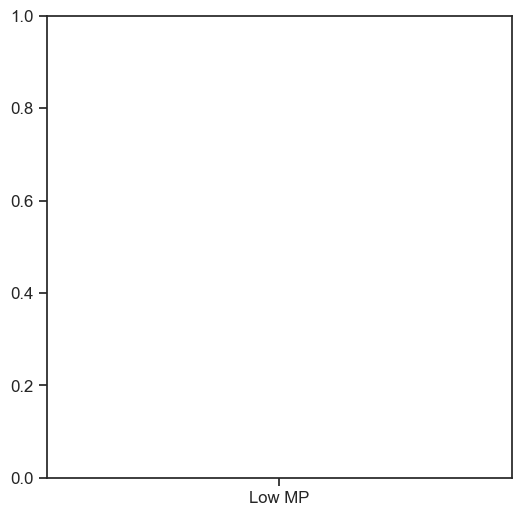

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style to match your other plots
sns.set_theme(style="ticks", font_scale=1.1)
plt.figure(figsize=(6, 6))

# Create the count plot
ax = sns.countplot(
    data=figure_3_data, 
    x='MP_label', 
    palette=color_scheme,
    order=['Low MP', 'High MP'] # Ensures consistent order
)

# Add the exact count numbers on top of the bars for clarity
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.title('Dataset Class Distribution', pad=20)
plt.xlabel('Melting Point Regime')
plt.ylabel('Number of Compounds')

# Remove the top and right spines for a "Nature-style" clean look
sns.despine()

plt.tight_layout()
plt.savefig(figure_output_dir + 'data_imbalance.png', dpi=300)
plt.show()